# 캐글 대회 데이터 EDA

In [104]:
# 필요한 모듈 임포트
import os, hds
import pandas as pd
import numpy as np
from plt_rcs import *

In [105]:
plt.rc(group='figure', figsize=(4, 4))

In [106]:
os.getcwd()

'c:\\Users\\pc\\Desktop\\Repo\\SeSAC\\study\\sesac_ml_dl_study_repo\\kaggle_data_2\\data'

In [107]:
os.chdir('../data')

In [108]:
sorted(os.listdir())

['sample_submission.csv', 'test.csv', 'train.csv']

In [109]:
# 데이터셋 불러오기
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [110]:
train.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Num ID
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,14860
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,47181
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,47182
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,47183
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,47184


In [111]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
 10  Num ID                   10000 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB


In [112]:
train.describe().round(3)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Num ID
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034,40711.266
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181,14870.161
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000,14860.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000,23214.750
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000,48861.500
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000,53001.500
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000,57174.000


In [113]:
train.describe(include=object)

,Product ID,Type,Failure Type
count,10000,10000,10000
unique,10000,3,6
top,M14860,L,No Failure
freq,1,6000,9652


## 데이터 전처리

In [114]:
train = train.drop(columns=['UDI', 'Num ID']).set_index(keys='Product ID')
train.columns = ['Type', 'AirTmp', 'ProcTmp', 'RotSpd', 'Torque', 'ToolWear', 'Target', 'F_Type']
train.head()

,Type,AirTmp,ProcTmp,RotSpd,Torque,ToolWear,Target,F_Type
Product ID,,,,,,,,
M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## EDA

In [115]:
train.columns

Index(['Type', 'AirTmp', 'ProcTmp', 'RotSpd', 'Torque', 'ToolWear', 'Target',
       'F_Type'],
      dtype='object')

In [116]:
train['Target'].value_counts(normalize=True)

Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [117]:
num_cols = train.select_dtypes([int, float]).columns

### Taeget과 숫자형 비교

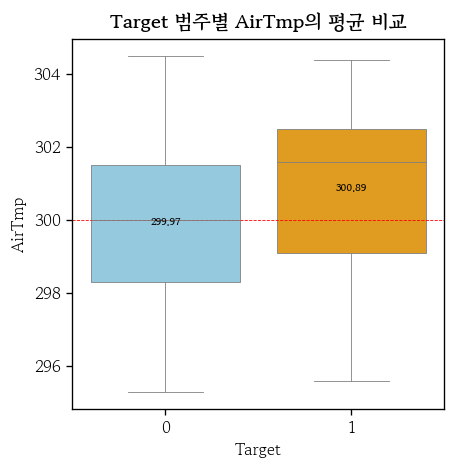

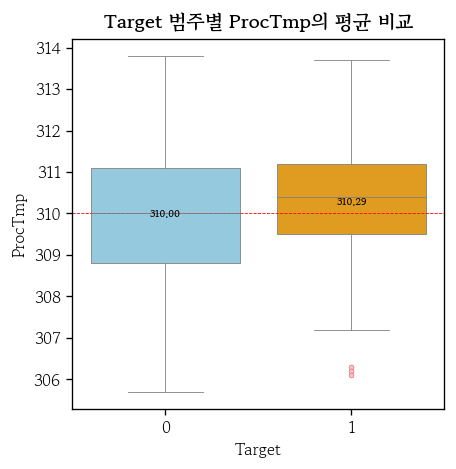

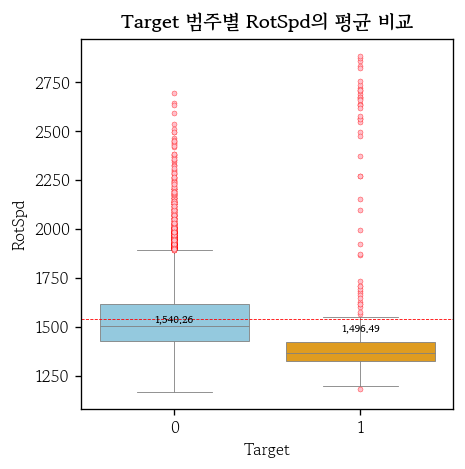

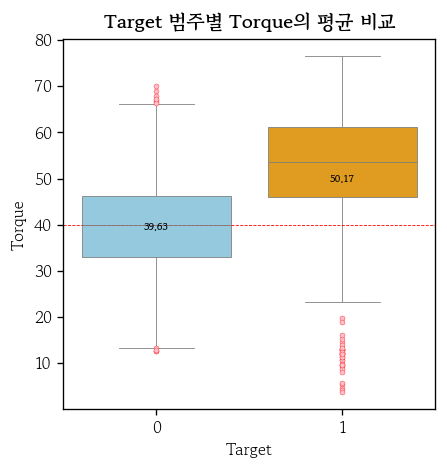

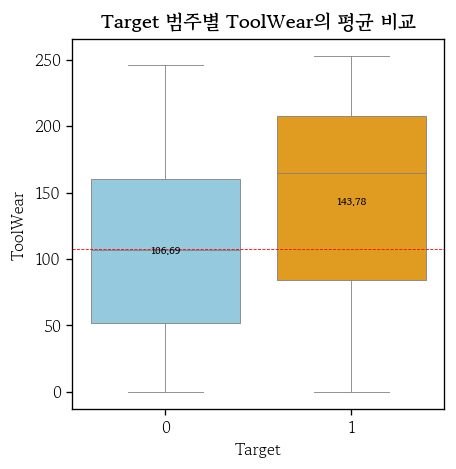

In [118]:
for i in range(len(num_cols) - 1):
    hds.plot.box_group(data=train, x='Target', y=num_cols[i], palette=['skyblue', 'orange'])
    plt.show()

### Target과 범주형 비교

In [119]:
train.select_dtypes(object).columns

Index(['Type', 'F_Type'], dtype='object')

In [120]:
train['Type'].value_counts().sort_index()

Type
H    1003
L    6000
M    2997
Name: count, dtype: int64

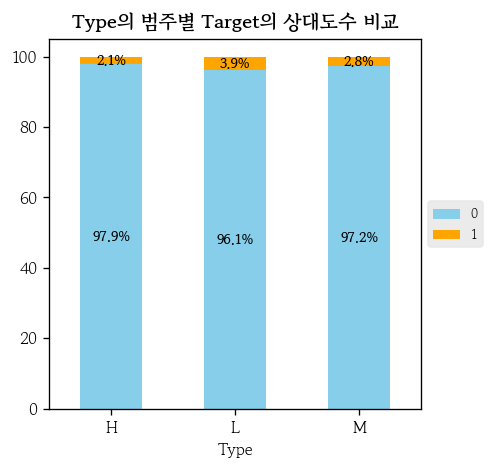

In [121]:
hds.plot.bar_stack_prop(data=train, x='Type', g='Target', palette=['skyblue', 'orange'])

### 히트맵

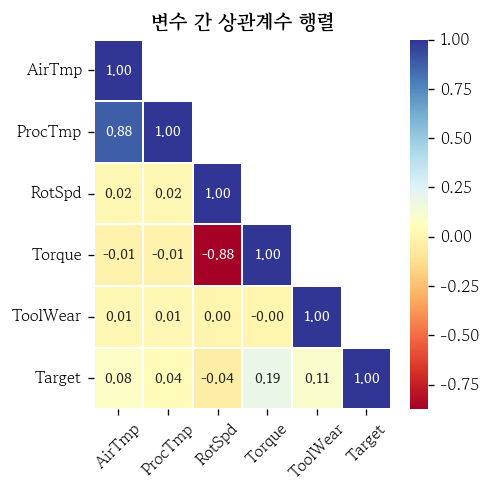

In [122]:
hds.plot.corr_heatmap(train)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.show()